In [1]:
import SimDAT2D.SimDAT2D_MDK as sim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IsoDAT2D.IsoDAT2D_MDK as iso
from PIL import Image
import pyFAI, fabio
from pyFAI.gui import jupyter
import pyFAI
import os
import matplotlib.pyplot as plt
from tifffile import imread
from SimDAT2D import masking
import pyFAI.azimuthalIntegrator as AI

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/opt/anaconda3/lib/python3.12/asyncio/base_events.py", line 641, in run_forever
    self._run_once()
  File "/opt/anaconda3/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once
    handle._run()
  File "/opt/anaconda3/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/opt/anaconda3/lib/python3.12/

In [2]:
# # to reload any iterative changes to the code, uncomment the following lines:
import importlib
sim = importlib.reload(sim)
iso = importlib.reload(iso)

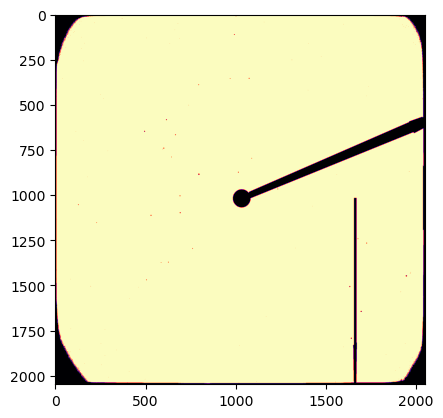

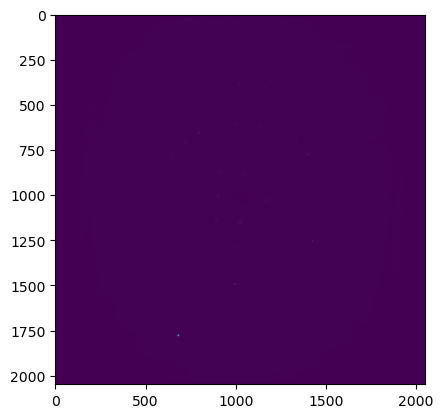

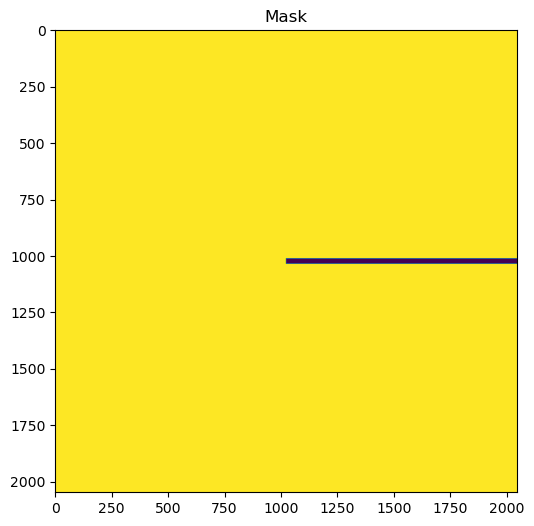

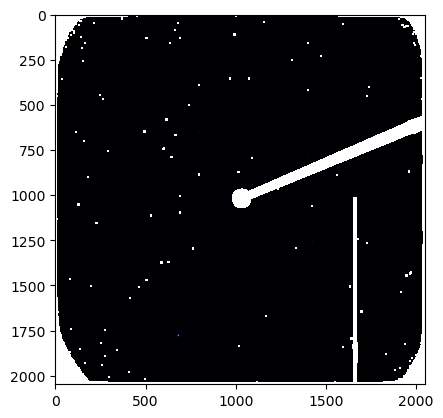

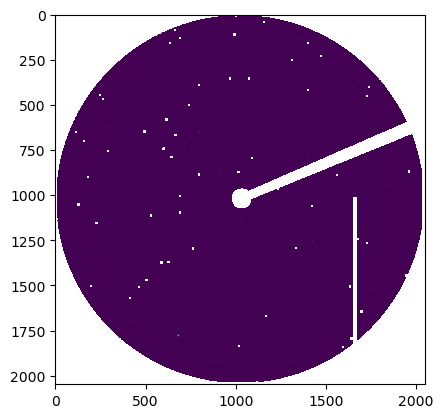

In [3]:
tm_mask_path = r'/Users/marisa/UFL Dropbox/Marisa Kelley/DNA&MDKShare/copy_data_isodat/perkin/masks/tm_mask_whole.npy'
tm_mask = np.load(tm_mask_path)
tm_inverted_mask = 1 - tm_mask
plt.imshow(tm_inverted_mask, cmap = 'magma')
plt.show()

exp_SC = r'/Users/marisa/UFL Dropbox/Marisa Kelley/DNA&MDKShare/copy_data_isodat/perkin/da_5_Si-00005/da_5_Si-00005.tiff'
exp_SC_im = imread(exp_SC)
plt.imshow(exp_SC_im)
plt.show()

#create integration mask
mask_12 = sim.create_mask(exp_SC_im, 12)

mask_with_nan = tm_inverted_mask.astype(float)
mask_with_nan[tm_inverted_mask == 0] = np.nan
plt.imshow(mask_with_nan, cmap = 'magma')

combined_image = exp_SC_im + mask_with_nan
plt.imshow(combined_image, cmap = 'magma')
plt.show() 

exp_SC_circle = sim.mask_circle_nan_edge(combined_image)
plt.imshow(exp_SC_circle)
plt.show()


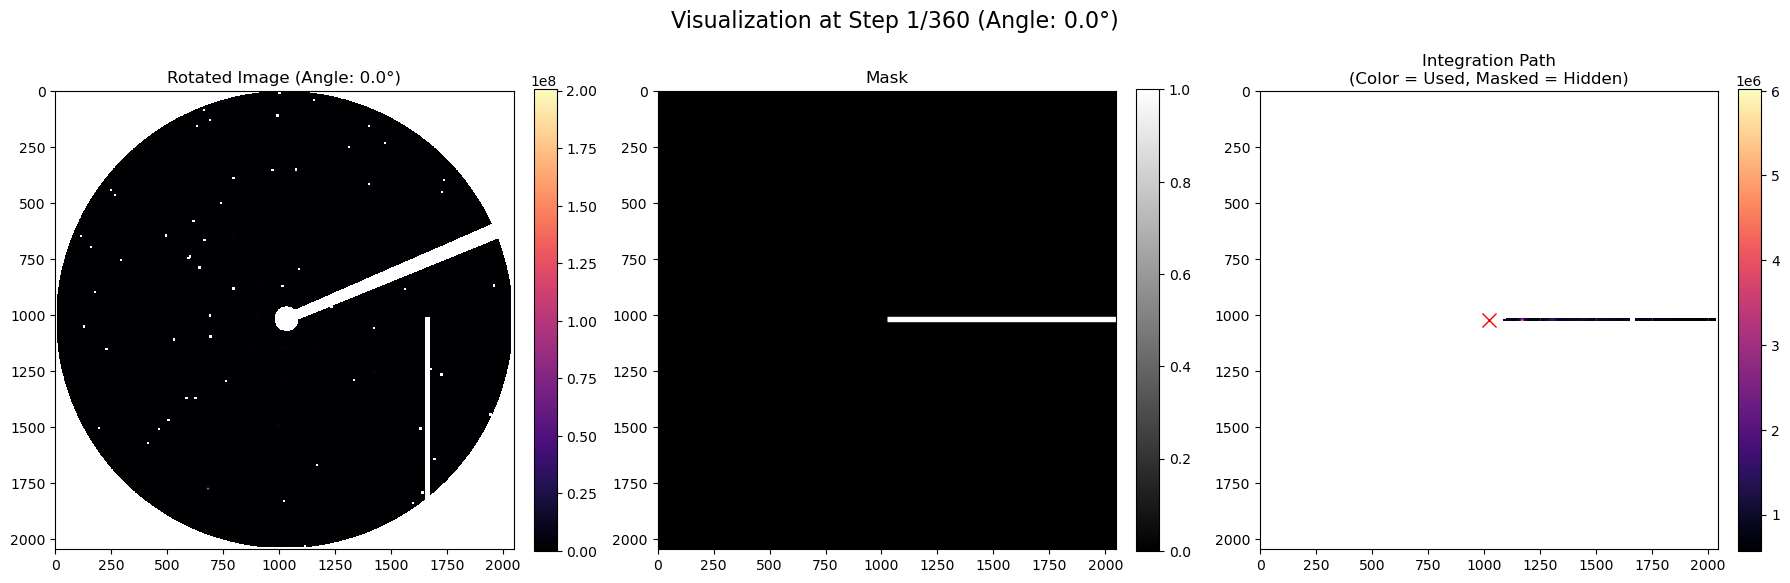

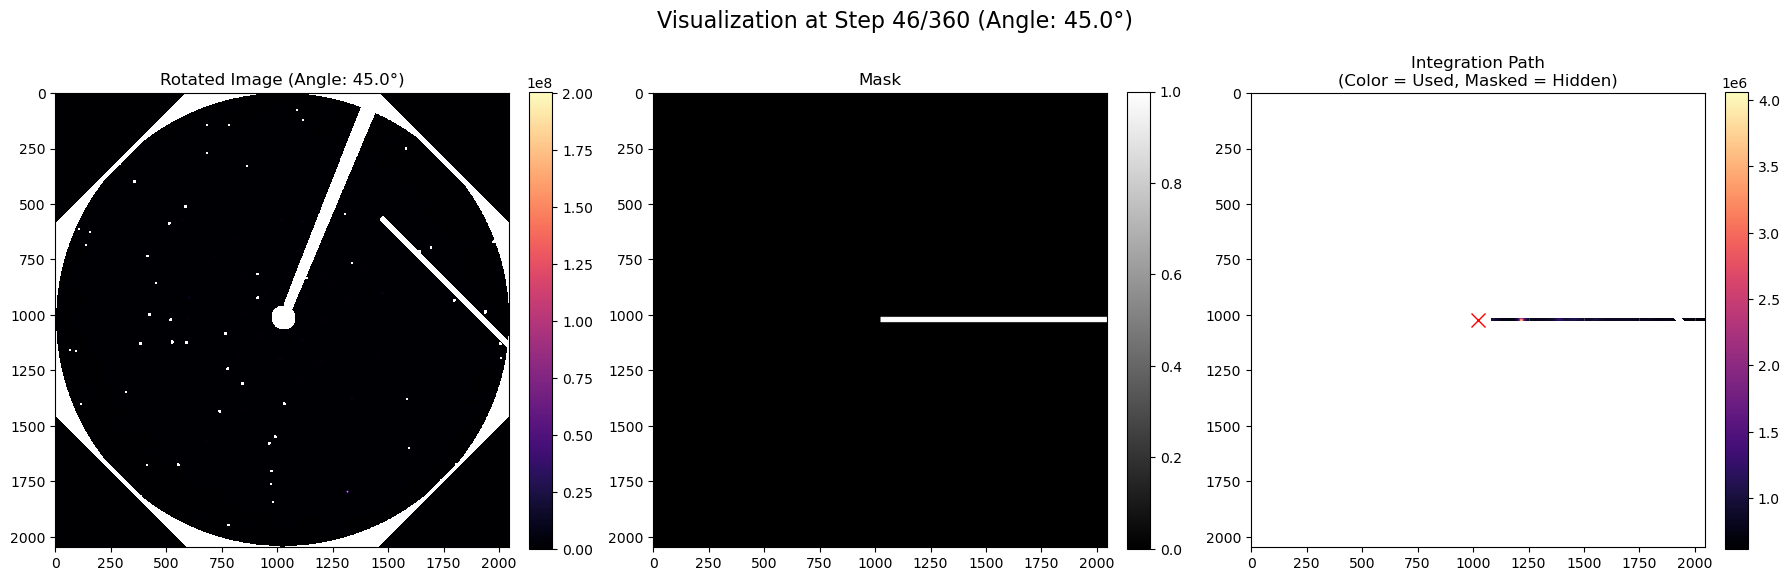

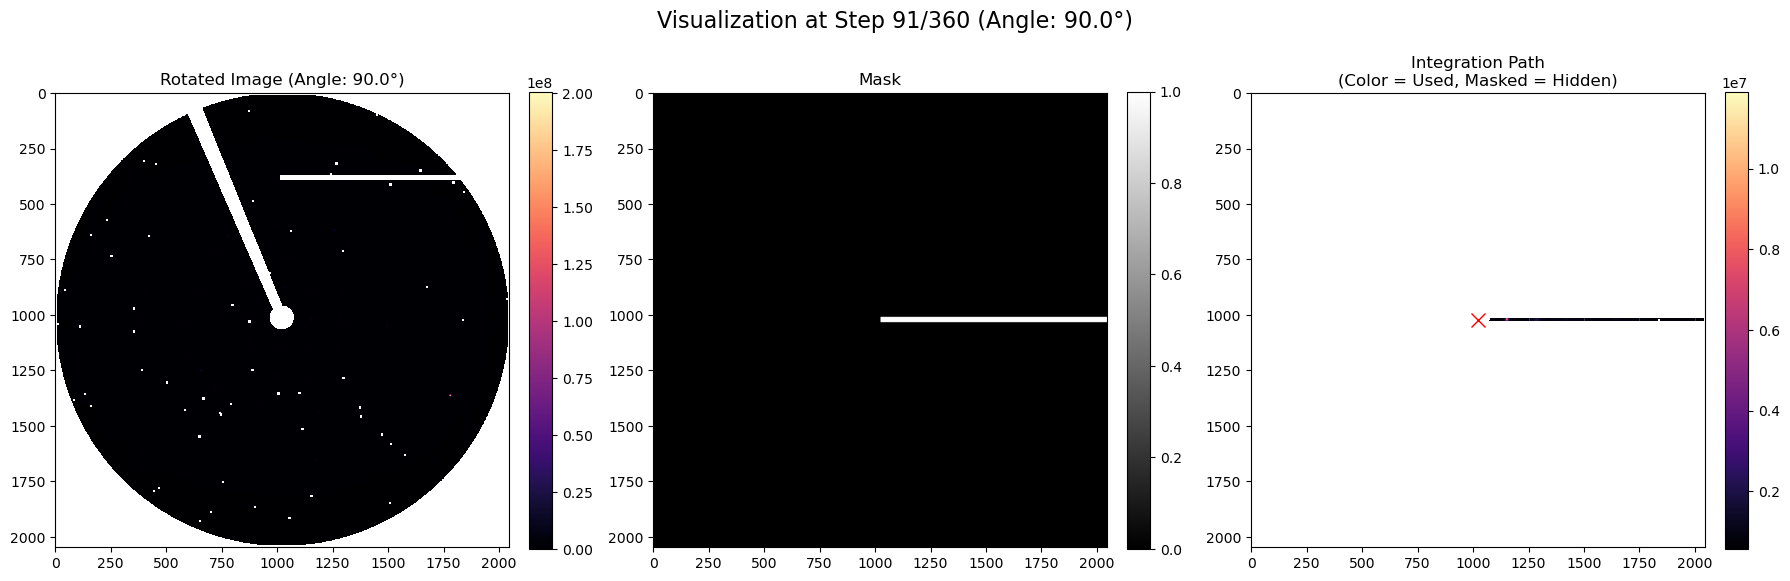

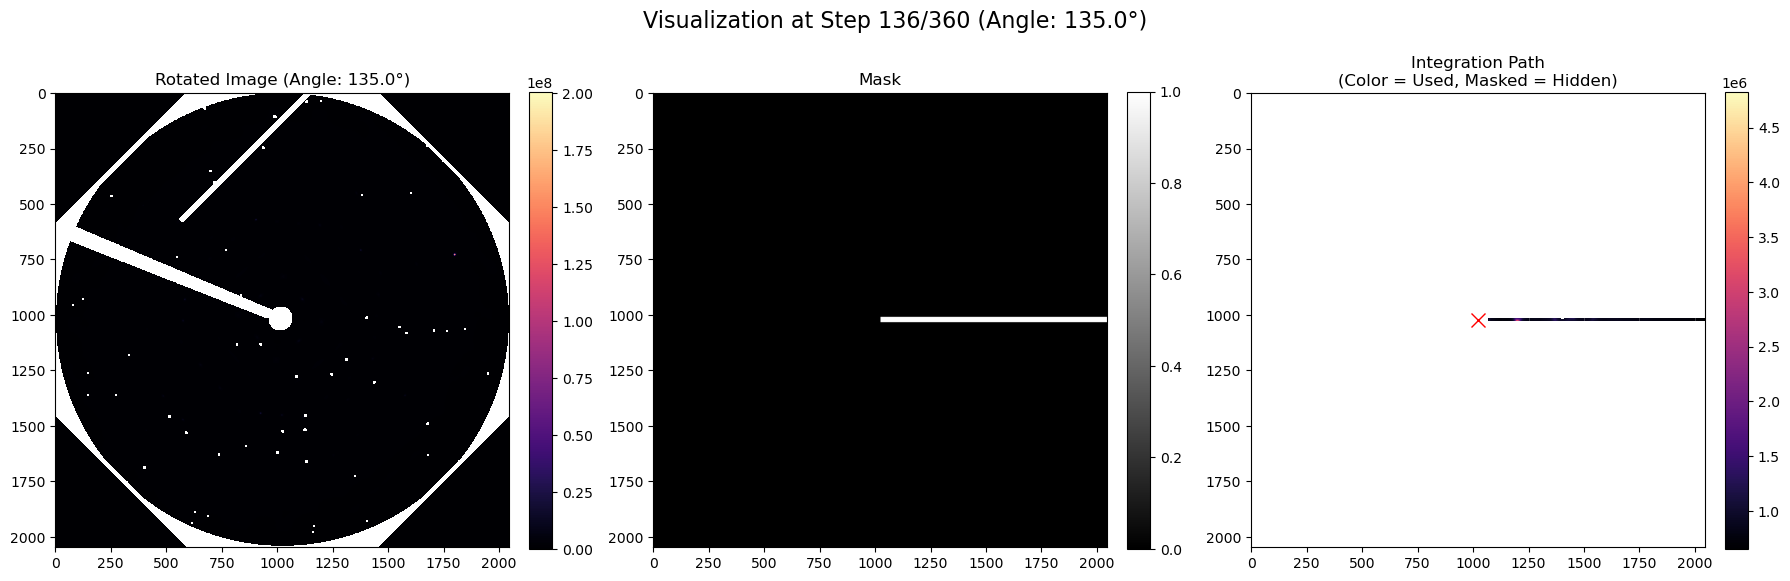

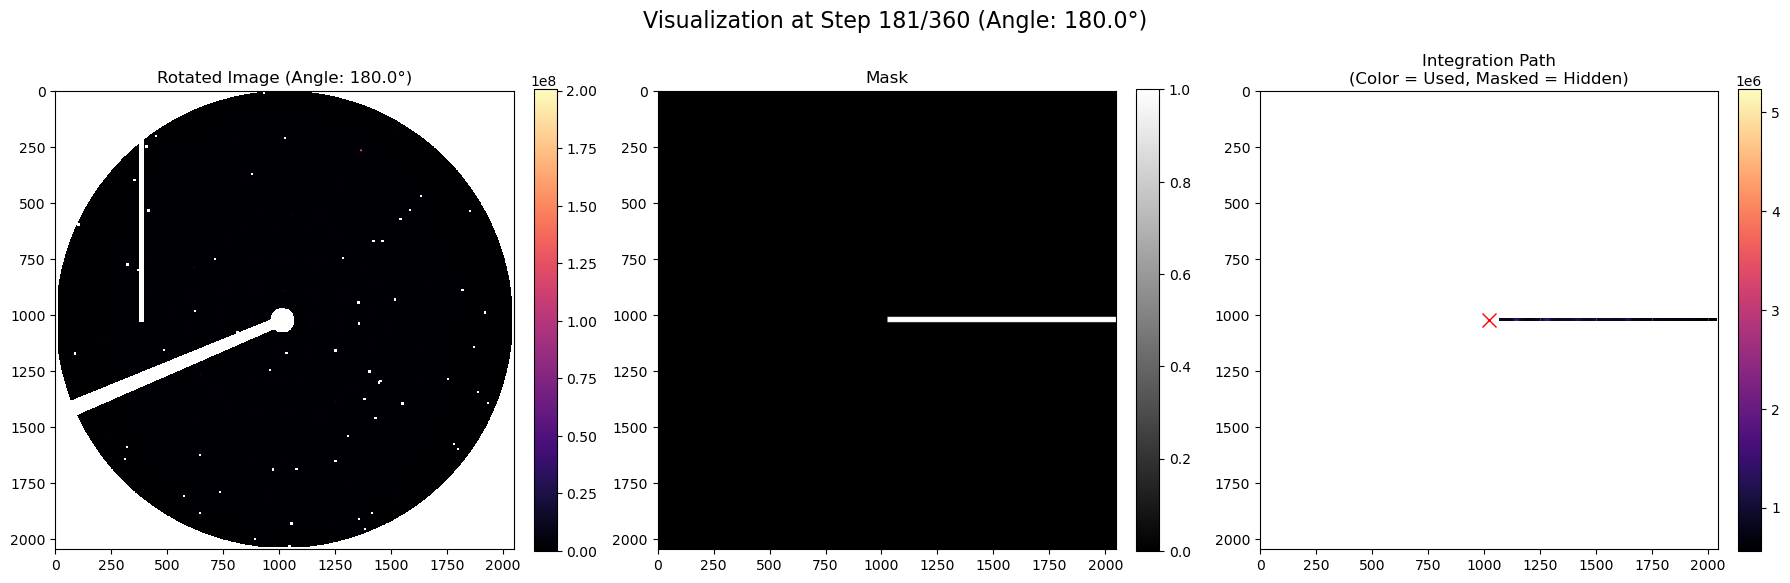

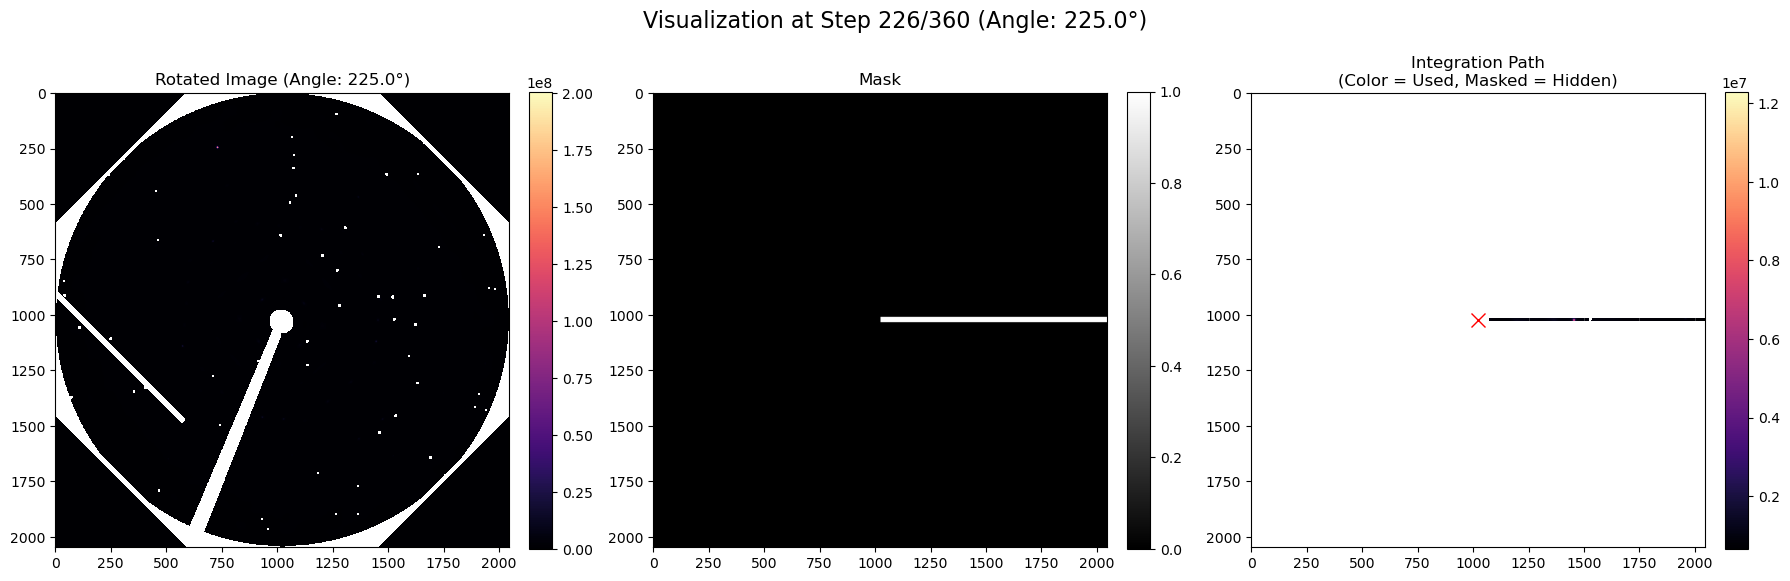

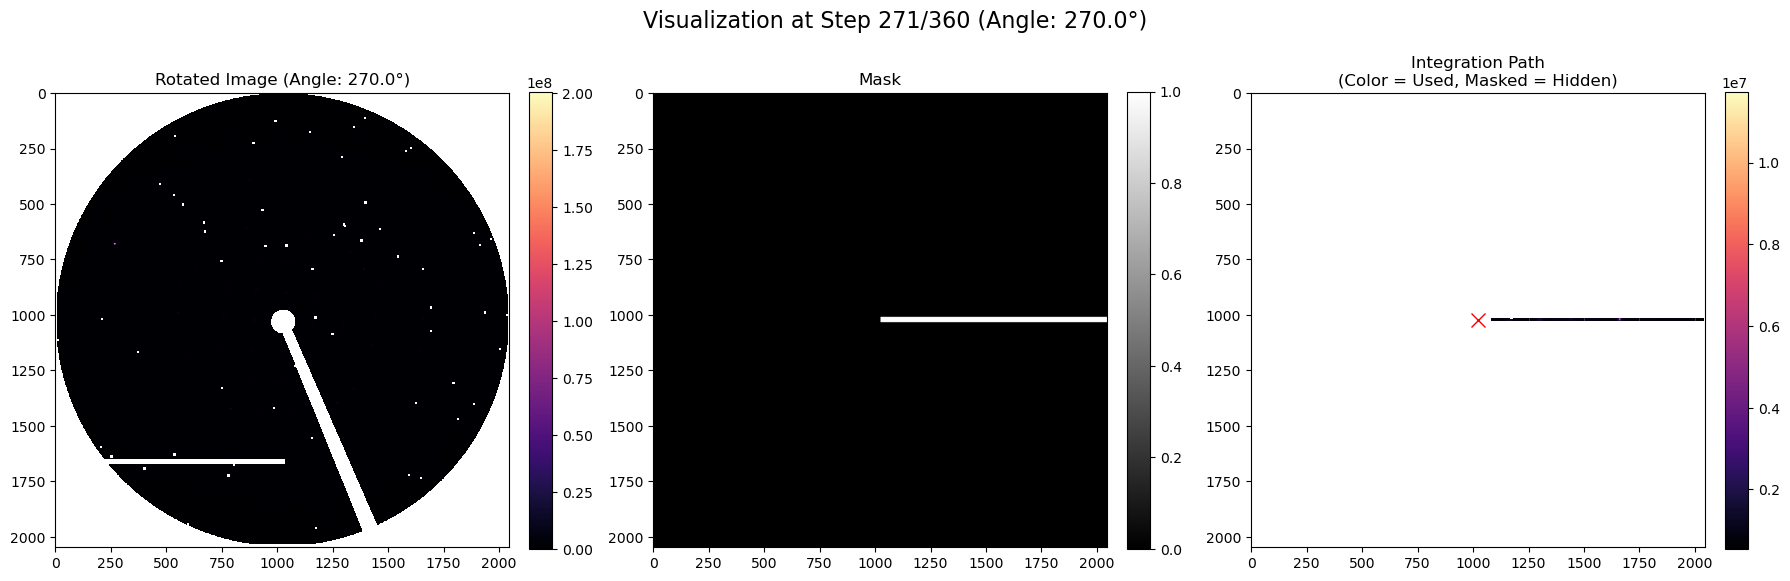

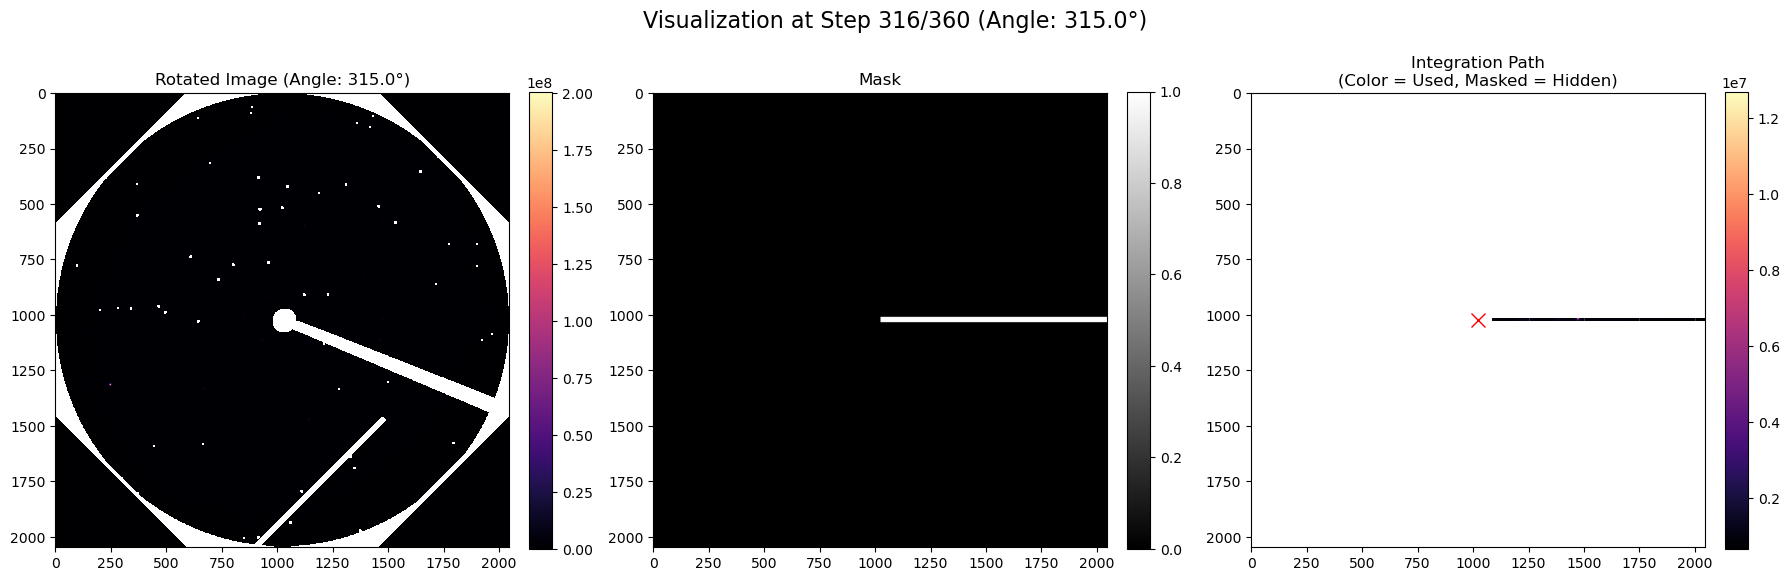

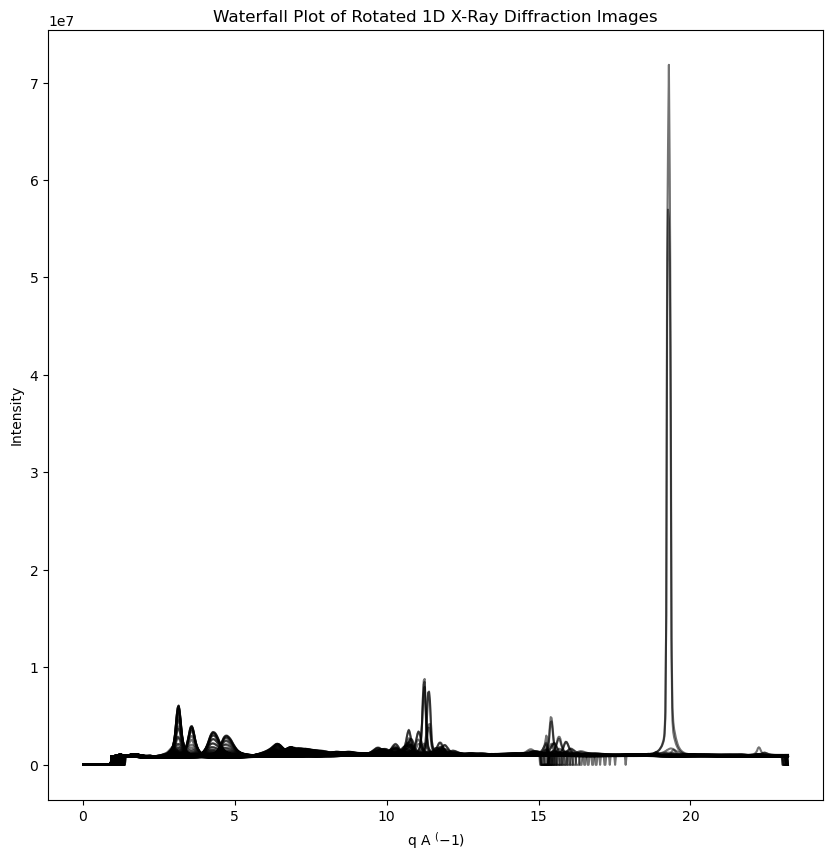

In [4]:
q, exp_SC_data = sim.rotate_and_integrate_printout(exp_SC_circle, 1, .41794313, 1.22224e-11, resolution = 800, mask = mask_12, center = None, vis_interval = 45)